# Taller 6: Morfología matemática

## Cargue y visualice la imagen morpho.png

In [1]:
PATH = './imagenes/'

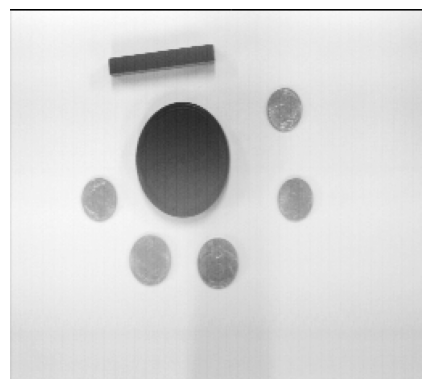

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen_morpho = cv2.imread(PATH + 'MORPHO.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(imagen_morpho, cmap='gray')
plt.axis('off')
plt.show()

## Haga una umbralización de esta imagen, para obtener objetos negros sobre fondo blanco (umbral alrededor de 115).

Aplicamos la umbralización y visualizamos el resultado.

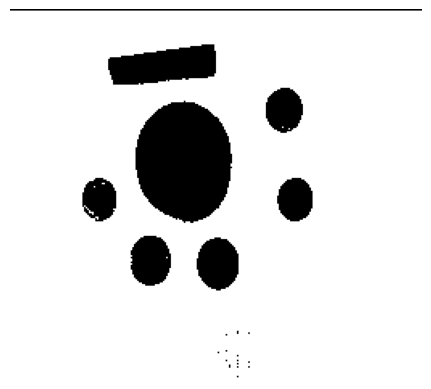

In [3]:
thres_value, thres_image = cv2.threshold(imagen_morpho, 115, 255, cv2.THRESH_BINARY)
plt.imshow(thres_image, cmap='gray')
plt.axis('off')
plt.show()

Se desea eliminar los objetos de dimensión pequeña. Para hacer esto, se va a reducir el tamaño de todos los objetos, hasta que quede únicamente el más grande. Después se "inflará" de nuevo el objeto que quedó. Recuerde que la erosión reduce el tamaño de los objetos claros y que la dilatación aumenta su tamaño. En nuestro caso, los objetos son oscuros. Por consiguiente, para reducir su tamaño, es necesario dilatar el fondo claro.

## Sobre la imagen binaria efectúe una dilatación con un elemento estructurante o máscara cuadrada de 29x29. ¿Qué obtiene como resultado?

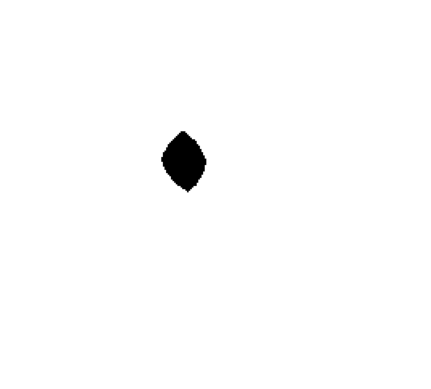

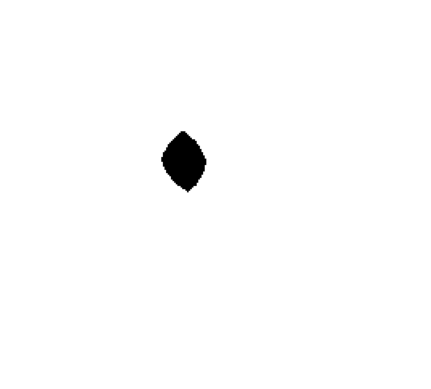

In [4]:
from skimage.morphology import dilation, binary_dilation, footprint_rectangle
fp = footprint_rectangle((29, 29))

binary_dilated_image = binary_dilation(thres_image, fp)

plt.imshow(binary_dilated_image, cmap='gray')
plt.axis('off')
plt.show()

dilated_image = dilation(thres_image, fp)
plt.imshow(dilated_image, cmap='gray')
plt.axis('off')
plt.show()

Vemos que ambas funciones binary_dilation y dilation nos dan el mismo resultado con el elemento estructurante en forma de cuadrado de 29x29. El resultado es una parte del objeto en forma de círculo de la imagen original.

## Sobre la imagen resultante, haga una erosión con la misma máscara. ¿Cómo es el objeto obtenido con respecto al original?

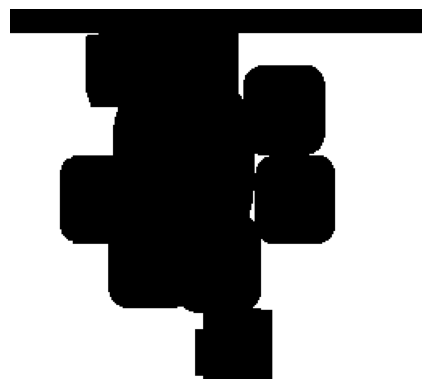

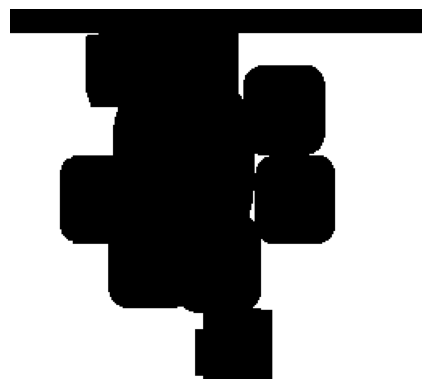

In [5]:
from skimage.morphology import erosion, binary_erosion
binary_eroded_image = binary_erosion(thres_image, fp)
plt.imshow(binary_eroded_image, cmap='gray')
plt.axis('off')
plt.show()
eroded_image = erosion(thres_image, fp)
plt.imshow(eroded_image, cmap='gray')
plt.axis('off')
plt.show()

La imagen resultante es lejana a la imagen original y simplemente es una superposición de cuadrados iguales al elemento estructurante que tienen como centro la imagen resultante luego de la umbralización y dilatación.

## Sobre la imagen resultado del punto anterior, haga una erosión con una máscara en cruz, de tamaño 11x11. Las máscaras en cruz deben crearse generando una matriz de nxn (tamaño deseado) y colocando 1’ s en la cruz. Los demás elementos se deben dejar vacíos (SIN CEROS).

In [6]:
from skimage.morphology import (
    footprint_rectangle,
    diamond,
    disk,
    octahedron,
    ball,
    octagon,
    star,
)

In [7]:
struct = diamond(3)
struct

array([[0, 0, 0, 1, 0, 0, 0],
       [0, 0, 1, 1, 1, 0, 0],
       [0, 1, 1, 1, 1, 1, 0],
       [1, 1, 1, 1, 1, 1, 1],
       [0, 1, 1, 1, 1, 1, 0],
       [0, 0, 1, 1, 1, 0, 0],
       [0, 0, 0, 1, 0, 0, 0]], dtype=uint8)

Tomamos como ejemplo un elemento estructurante de la librería skimage. Podemos ver como el array resultante SÍ tiene ceros.

In [8]:
import numpy as np

# Crear elemento estructurante en forma de cruz de 11x11 con valores booleanos
n = 11
cruz = np.full((n, n), 0)  # Matriz de False (vacíos)

# Índice del medio
medio = n // 2  # esto da 5 para n=11

# Colocar True en la fila del medio
cruz[medio, :] = True

# Colocar True en la columna del medio
cruz[:, medio] = True

# Visualizar la cruz
print(cruz)

[[0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0]]


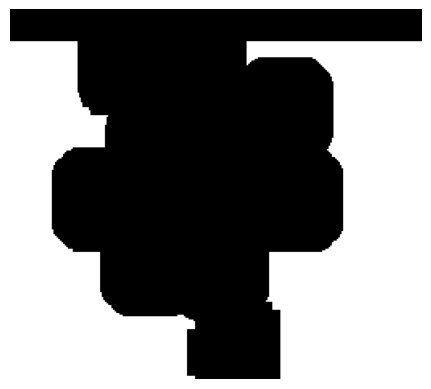

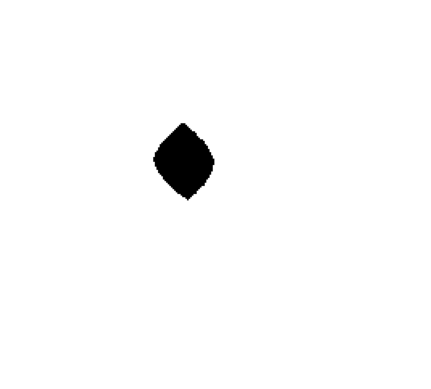

In [9]:
from skimage.morphology import erosion

imagen_erosionada_cruz = erosion(eroded_image, footprint=cruz)

plt.imshow(imagen_erosionada_cruz, cmap='gray')
plt.axis('off')
plt.show()

imagen_erosionada_dilacion_cruz = erosion(dilated_image, footprint=cruz)
plt.imshow(imagen_erosionada_dilacion_cruz, cmap='gray')
plt.axis('off')
plt.show()

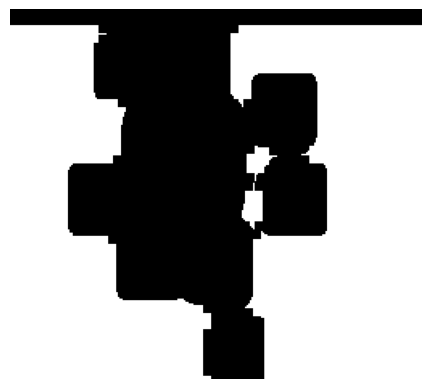

In [10]:
# Invertir la imagen para que objetos sean claros
imagen_invertida = 255 - eroded_image

# Aplicar erosión
imagen_erosionada_cruz = erosion(imagen_invertida, footprint=cruz)

# Invertir de vuelta
imagen_erosionada_cruz = 255 - imagen_erosionada_cruz

plt.imshow(imagen_erosionada_cruz, cmap='gray')
plt.axis('off')
plt.show()

## Calcule el máximo entre esta última imagen y la imagen original umbralizada. ¿Cómo es el resultado obtenido?

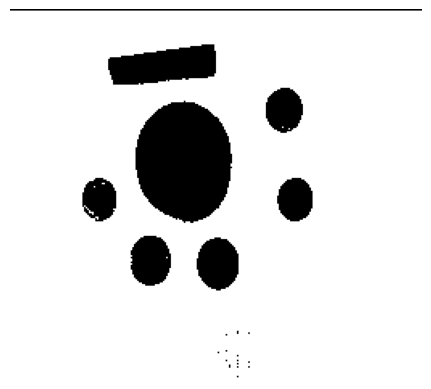

In [11]:
# Calcular el máximo píxel a píxel
imagen_maxima = np.maximum(imagen_erosionada_cruz, thres_image)

plt.imshow(imagen_maxima, cmap='gray')
plt.axis('off')
plt.show()

Al hacer máximo queda como resultado la imagen original umbralizada.

## Repita las operaciones 1 a 4, trabajando directamente con la imagen original no umbralizada (en niveles de gris).

Empezamos con la dilatación con elemento estructurante cuadrado de 29x29 sobre imagen en niveles de gris. Queda un objeto pequeño en forma de rombo.

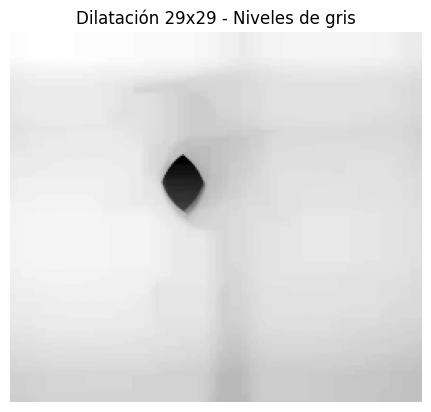

In [12]:
from skimage.morphology import dilation, erosion, footprint_rectangle
import numpy as np

fp = footprint_rectangle((29, 29))

dilated_image_gray = dilation(imagen_morpho, footprint=fp)

plt.imshow(dilated_image_gray, cmap='gray')
plt.axis('off')
plt.title('Dilatación 29x29 - Niveles de gris')
plt.show()

Luego, aplicamos erosión con la misma máscara 29x29. Aparece un objeto con forma de octágono.

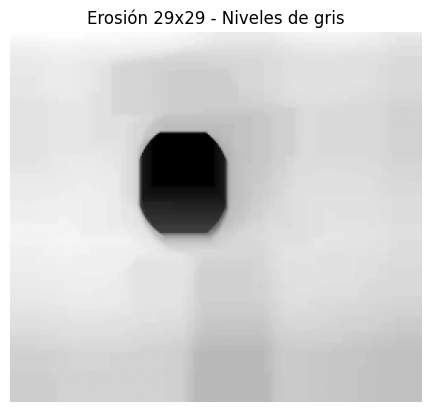

In [13]:
eroded_image_gray = erosion(dilated_image_gray, footprint=fp)

plt.imshow(eroded_image_gray, cmap='gray')
plt.axis('off')
plt.title('Erosión 29x29 - Niveles de gris')
plt.show()

Seguimos con la erosión con máscara en cruz de 11x11. Vemos como se vuelve más ancho el objeto en forma de octágono.

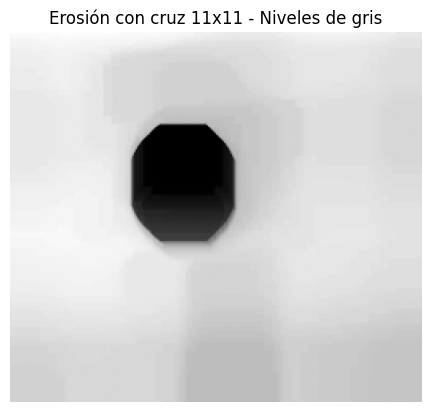

In [14]:
n = 11
cruz = np.full((n, n), 0)
medio = n // 2
cruz[medio, :] = 1
cruz[:, medio] = 1

imagen_erosionada_cruz_gray = erosion(eroded_image_gray, footprint=cruz)

plt.imshow(imagen_erosionada_cruz_gray, cmap='gray')
plt.axis('off')
plt.title('Erosión con cruz 11x11 - Niveles de gris')
plt.show()

Finalizamos con el máximo entre la iamgen obtenida con la imagen original en nivles de grises.

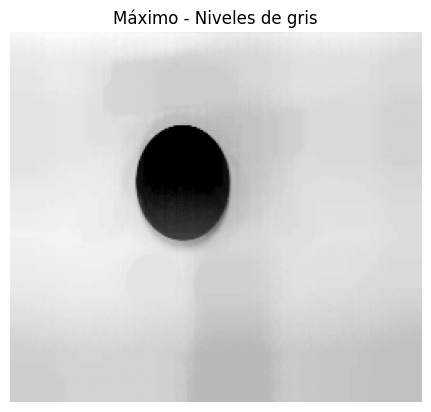

In [15]:
imagen_maxima_gray = np.maximum(imagen_erosionada_cruz_gray, imagen_morpho)

plt.imshow(imagen_maxima_gray, cmap='gray')
plt.axis('off')
plt.title('Máximo - Niveles de gris')
plt.show()

Logramos recuperar el círculo grande de la imagen original, el cuál era el objetivo del tratamiento con dilatación y erosión.

## ¿Cómo funcionan las operaciones de erosión y de dilatación en imágenes en niveles de gris?

**Dilatación:** La operación de consiste en que para cada píxel, coloca el elemento estructurante centrado en ese píxel y toma el valor máximo de todos los píxeles cubiertos por el elemento estructurante. Así, la operación expande las regiones claras (valores altos de intensidad) y reduce las regiones oscuras.

**Erosión:** La operación de consiste en que para cada píxel, coloca el elemento estructurante centrado en ese píxel y toma el valor mínimo de todos los píxeles cubiertos por el elemento estructurante. Así, la operación expande las regiones oscuras (valores bajos de intensidad) y reduce las regiones claras.

Las operaciones morfológicas en niveles de gris preservan los gradientes y transiciones suaves. La dilatación logra expandir las regiones claras considerando los valores de intensidad. Las operaciones 

## ¿Cómo es el resultado obtenido sobre la imagen en niveles de gris, comparado con el resultado sobre la imagen binaria?

El resultado obtenido sobre la imagen en niveles de gris es que se logra el objetivo de eliminar objetos pequeños. Mientras que en la imagen binaria el máximo recupera completamente la imagen original umbralizada (incluyendo todos los objetos pequeños), en niveles de gris solo se recupera el círculo grande con sus gradientes originales. Esto se debe a que las operaciones morfológicas en niveles de gris preservan información de intensidad y permiten una reconstrucción selectiva basada en valores de intensidad, no solo en presencia/ausencia binaria. Además, el resultado en niveles de gris mantiene transiciones suaves y texturas que se pierden completamente en el procesamiento binario.